___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright Pierian Data</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Forecasting Exercises
This exercise walks through a SARIMA prediction and forecast similar to the one done on the Mauna Loa CO₂ dataset.<br>
This time we're using a seasonal time series of California Hospitality Industry Employees.

<div class="alert alert-danger" style="margin: 10px"><strong>IMPORTANT NOTE!</strong> Make sure you don't run the cells directly above the example output shown, <br>otherwise you will end up writing over the example output!</div>

In [1]:
# RUN THIS CELL
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

%config InlineBackened.figure_format = "svg"

# Load specific forecasting tools
from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.graphics.tsaplots import plot_acf,plot_pacf # for determining (p,q) orders
from statsmodels.tsa.seasonal import seasonal_decompose      # for ETS Plots
from pmdarima import auto_arima                              # for determining ARIMA orders

# Load specific evaluation tools
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse

# Ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")

# Load datasets
df = pd.read_csv('../Data/HospitalityEmployees.csv',index_col='Date',parse_dates=True)
df.index.freq = 'MS'
print(len(df))
print(df.head())

348
            Employees
Date                 
1990-01-01     1064.5
1990-02-01     1074.5
1990-03-01     1090.0
1990-04-01     1097.4
1990-05-01     1108.7


So <tt>df</tt> has 348 records and one column. The data represents the number of employees in thousands of persons as monthly averages from January, 1990 to December 2018.

### 1. Plot the source data
Create a line chart of the dataset. Optional: add a title and y-axis label.

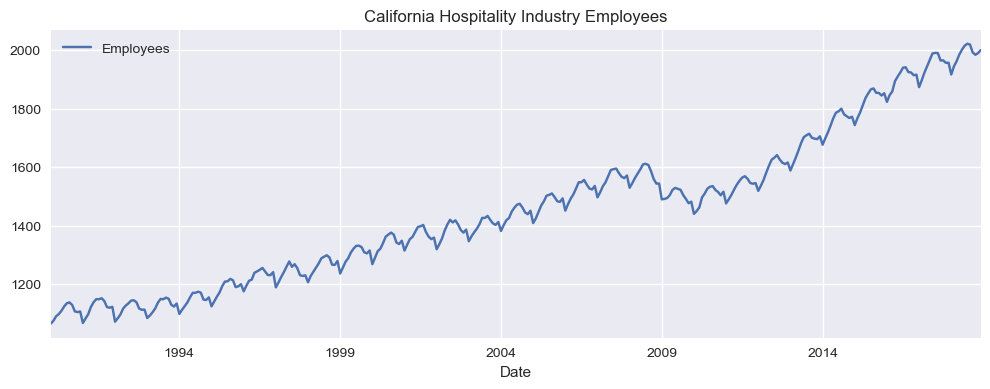

In [2]:
## CODE HERE
df.plot(figsize = (12,4), title = "California Hospitality Industry Employees")
plt.show()

### 2. Run an ETS Decomposition
Use an 'additive' model.

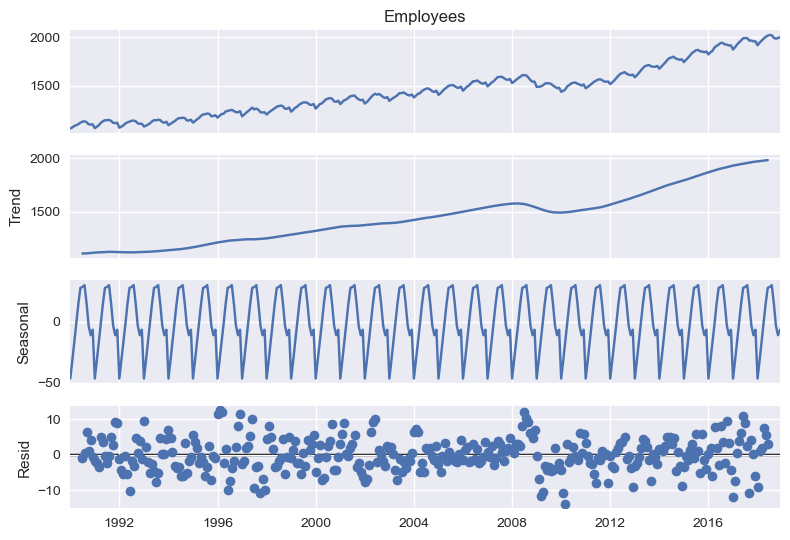

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose      # for ETS Plots 
result = seasonal_decompose(df["Employees"], model = "additive")
result.plot()
plt.show()


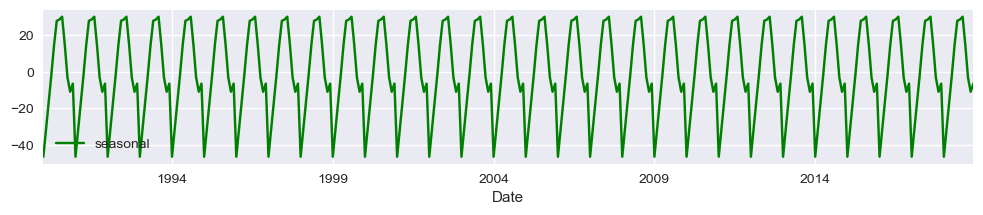

In [5]:
result.seasonal.plot(figsize = (12,2), color ="green", legend = True);

seasonality: 12 month


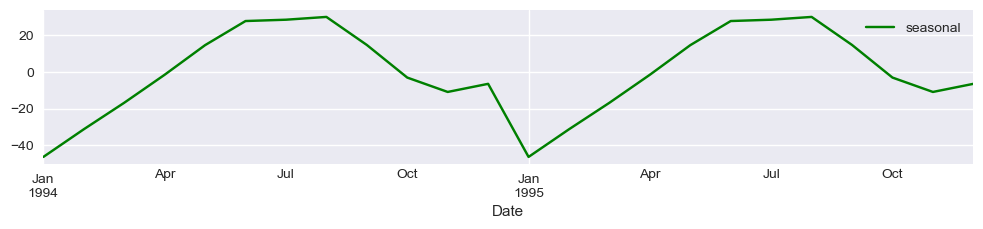

In [8]:
print("seasonality: 12 month")
result.seasonal.loc["1994":"1995"].plot(figsize = (12,2), color ="green", legend = True);

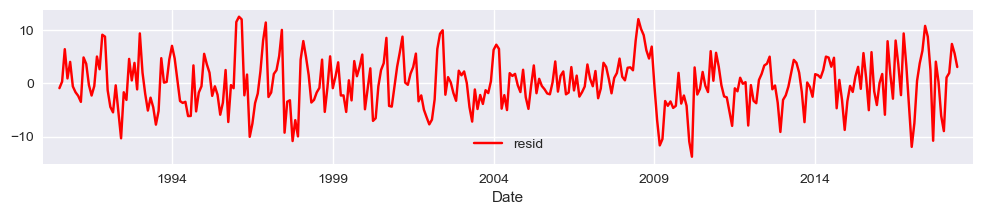

In [9]:
result.resid.plot(figsize = (12,2), color ="red", legend = True);

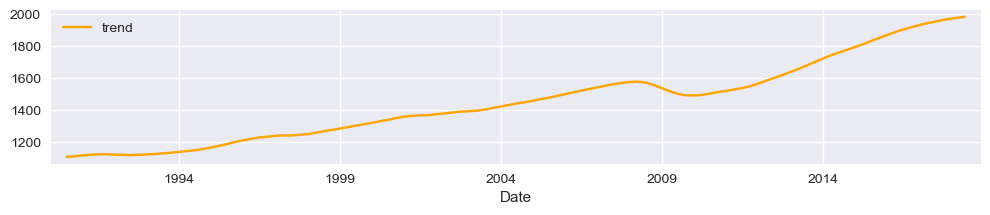

In [11]:
result.trend.plot(figsize = (12,2), color ="orange", legend = True);

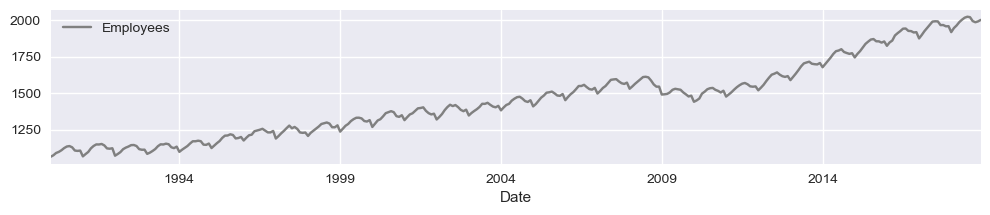

In [12]:
result.observed.plot(figsize = (12,2), color ="gray", legend = True);

### 3. Run <tt>pmdarima.auto_arima</tt> to obtain recommended orders
This may take awhile as there are a lot of combinations to evaluate.

In [ ]:
from pmdarima import auto_arima


In [ ]:
stepwise_fit = auto_arima(y = df["Employees"] , seasonal=True , trace=True , m = 12)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=2214.039, Time=0.71 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2974.636, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2707.381, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2980.790, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=2340.936, Time=0.40 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=2229.816, Time=1.63 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=2255.048, Time=1.95 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=1.25 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=2264.870, Time=1.17 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=inf, Time=1.86 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=2210.621, Time=0.82 sec
 ARIMA(1,1,2)(0,0,1)[12] intercept   : AIC=2

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  348
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 12)   Log Likelihood               -1098.252
Date:                              Fri, 10 Apr 2026   AIC                           2208.504
Time:                                      10:56:27   BIC                           2231.600
Sample:                                  01-01-1990   HQIC                          2217.700
                                       - 12-01-2018                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9245      0.045     20.605      0.000       0.837       1.012
ma.L1         -0.9441      0.070    -13.452      0.000      -1.082      -0.807
ma.L2          0.1288      0.060      2.135      0.033       0.011       0.247
ar.S.L12       0.9972      0.001    703.217      0.000       0.994       1.000
ma.S.L12      -0.7490      0.043    -17.319      0.000      -0.834      -0.664
sigma2        29.2963      1.717     17.063      0.000      25.931      32.661
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                67.42
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.86   Skew:                            -0.11
Prob(H) (two-sided):                  0.40   Kurtosis:                         5.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [20]:
stepwise_fit.order , stepwise_fit.seasonal_order

((1, 1, 2), (1, 0, 1, 12))

In [4]:
# DON'T WRITE HERE

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Statespace Model Results                                 
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  348
Model:             SARIMAX(0, 1, 0)x(2, 0, 0, 12)   Log Likelihood               -1134.664
Date:                            Wed, 27 Mar 2019   AIC                           2277.328
Time:                                    13:12:10   BIC                           2292.726
Sample:                                         0   HQIC                          2283.459
                                            - 348                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0477      0.292     -0.163      0.870      -0.620       0.524
ar.S.L12       0.5291      0.040     13.286      0.000       0.451       0.607
ar.S.L24       0.4303      0.041     10.453      0.000       0.350       0.511
sigma2        37.2952      2.157     17.294      0.000      33.068      41.522
===================================================================================
Ljung-Box (Q):                       99.53   Jarque-Bera (JB):                51.67
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.86   Skew:                            -0.29
Prob(H) (two-sided):                  0.42   Kurtosis:                         4.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

You should see a recommended ARIMA Order of (0,1,0) combined with a seasonal order of (2,0,0,12).
### 4. Split the data into train/test sets
Set one year (12 records) for testing. There is more than one way to do this!

In [23]:
m = 12 # seasonality
train = df.iloc[:len(df)-m]
test = df.iloc[-m:]
print(f"length of the dataframe: {len(df)}")
print(f"length of the training set: {len(train)}")
print(f"length og the test set: {len(test)}")

length of the dataframe: 348
length of the training set: 336
length og the test set: 12


In [5]:
# DON'T WRITE HERE

### 5. Fit a SARIMA(0,1,0)(2,0,0,12) model to the training set

In [27]:
stepwise_fit.order , stepwise_fit.seasonal_order

((1, 1, 2), (1, 0, 1, 12))

In [28]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_SARIMAX = SARIMAX(endog=train , order = stepwise_fit.order , seasonal_order=stepwise_fit.seasonal_order)
result_SARIMAX = model_SARIMAX.fit()
result_SARIMAX.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                            Employees   No. Observations:                  336
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 12)   Log Likelihood               -1058.058
Date:                              Fri, 10 Apr 2026   AIC                           2128.116
Time:                                      12:01:19   BIC                           2151.001
Sample:                                  01-01-1990   HQIC                          2137.240
                                       - 12-01-2017                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9240      0.044     21.179      0.000       0.839       1.010
ma.L1         -0.9583      0.070    -13.658      0.000      -1.096      -0.821
ma.L2          0.1497      0.061      2.462      0.014       0.031       0.269
ar.S.L12       0.9973      0.001    727.459      0.000       0.995       1.000
ma.S.L12      -0.7518      0.044    -17.157      0.000      -0.838      -0.666
sigma2        28.7656      1.685     17.076      0.000      25.464      32.067
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                73.32
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.91   Skew:                            -0.17
Prob(H) (two-sided):                  0.63   Kurtosis:                         5.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### 6. Obtain predicted values

In [30]:
start = len(train)
end =len(train) + len(test) - 1
prediction_SARIMAX = result_SARIMAX.predict(start=start , 
                                            end = end , 
                                            dynamic=False , 
                                            typ = "levels").rename(f"SARIMAX PREDICATIONS {stepwise_fit.order} {stepwise_fit.seasonal_order}")
prediction_SARIMAX

2018-01-01    1922.288104
2018-02-01    1941.849939
2018-03-01    1959.860357
2018-04-01    1983.213202
2018-05-01    2002.919630
2018-06-01    2019.452871
2018-07-01    2026.318925
2018-08-01    2028.259676
2018-09-01    2009.878240
2018-10-01    2004.789528
2018-11-01    1996.736981
2018-12-01    2000.539177
Freq: MS, Name: SARIMAX PREDICATIONS (1, 1, 2) (1, 0, 1, 12), dtype: float64

In [7]:
# DON'T WRITE HERE

### 7. Plot predictions against known values
Optional: add a title and y-axis label.

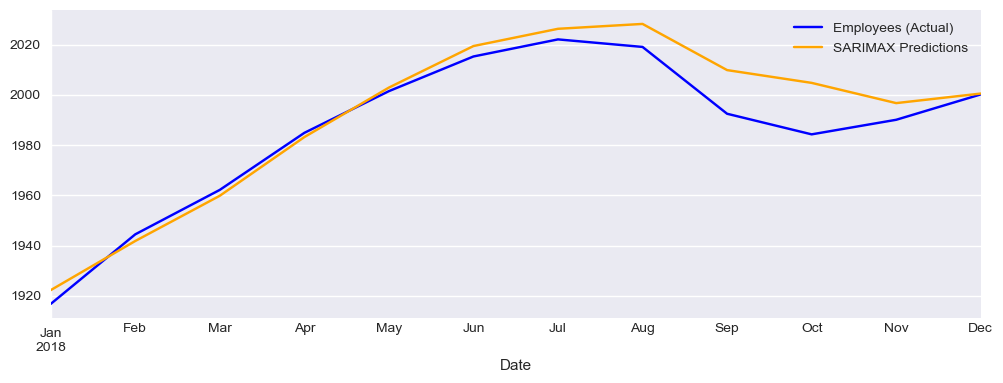

In [32]:
df["Employees"].loc["2018":].plot(figsize = (12,4), color ="blue", label = "Employees (Actual)", legend = True)
prediction_SARIMAX.plot(figsize = (12,4) , color ="orange" , label = "SARIMAX Predictions" , legend = True)
plt.show()

### 8. Evaluate the Model using MSE and RMSE
You can run both from the same cell if you want.

In [ ]:
from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import mean_squared_error as mse

len(prediction_SARIMAX) , len(test)

(12, 12)

In [69]:
type(test.values) , type(prediction_SARIMAX.values)

(numpy.ndarray, numpy.ndarray)

In [83]:
print(f"RMSE {prediction_SARIMAX.name}: {rmse(test.Employees , prediction_SARIMAX)}")
print(f"MSE {prediction_SARIMAX.name}: {mse(test , prediction_SARIMAX.values)}")

RMSE SARIMAX PREDICATIONS (1, 1, 2) (1, 0, 1, 12): 8.814810187532697
MSE SARIMAX PREDICATIONS (1, 1, 2) (1, 0, 1, 12): 77.70087864223022


### 9. Retrain the model on the full data and forecast one year into the future

In [91]:
model_SARIMAX_Full = SARIMAX(endog=df["Employees"], order = stepwise_fit.order , seasonal_order= stepwise_fit.seasonal_order)
result_Full = model_SARIMAX_Full.fit()
fcast = result_Full.predict(start = len(df) , end =len(df)+ 5 *11 , typ = "levels").rename(f"SARIMAX {stepwise_fit.order}{stepwise_fit.seasonal_order}")
fcast.head()

2019-01-01    1963.875384
2019-02-01    1986.816075
2019-03-01    2005.997036
2019-04-01    2030.332181
2019-05-01    2050.312855
Freq: MS, Name: SARIMAX (1, 1, 2)(1, 0, 1, 12), dtype: float64

In [10]:
# DON'T WRITE HERE

### 10. Plot the forecasted values alongside the original data
Optional: add a title and y-axis label.

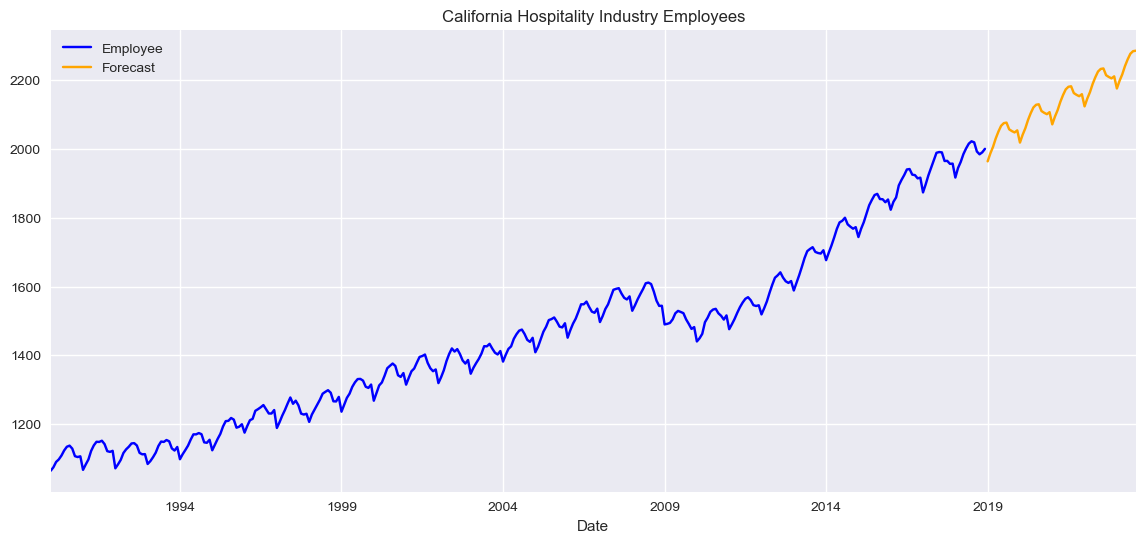

In [92]:
plt.title("California Hospitality Industry Employees")
df["Employees"].plot(figsize=(14,6), label = "Employee" , color ="blue", legend= True)
fcast.plot(figsize = (14,6), label = "Forecast" , color ="orange", legend = True)
plt.show()

## Great job!